<a href="https://colab.research.google.com/github/Annika0723/PINNs-for-Beam-Deflection/blob/main/DEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 引入工具、環境配置、確定硬體

In [2]:
import torch
from torch.autograd import grad
import numpy as np
import matplotlib.pyplot as plt
import random

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

torch.manual_seed(2026)
np.random.seed(2026)

# 2. 結構材料參數設定

## 模擬的物理模型，像是一根長 10 公尺、高 1 公尺、由混凝土製成的梁，受到了向下的均布載重。

In [3]:
class DistributedLoadConfig:
    Length = 10.0      # 梁長度 L
    Height = 1.0      # 梁高度 h
    Thickness = 1.0   # 梁厚度 b (平面應力假設厚度為 1.0)
    Nx = 200           # X 方向離散網格數
    Ny = 20           # Y 方向離散網格數
    iteration = 300    # LBFGS 優化演算法（一種常用於物理模擬的高階擬牛頓優化法）的疊代次數。
    lr = 0.05          # 學習率（Learning Rate），控制優化器每次更新參數的步長。

    # 材料力學參數
    E = 25e9         # 25 GPa (混凝土標準彈性模數)
    nu = 0.3         # Poisson's Ratio

    # 全梁受均布載荷 w (向下為負，單位長度受力)
    w_load = -80000.0

cf = DistributedLoadConfig()
I_moment = (cf.Thickness * (cf.Height**3)) / 12.0  # 慣性矩 I = bh^3/12

# 3. 線性彈性材料模型

這段程式碼是（PINNs）中最核心的部分。利用 PyTorch 的自動微分功能，直接計算連續體力學中的應變張量，並透過彈性力學的本構關係，計算出梁內部的應變能密度（Stored Strain Energy Density）。

在變分法（Variational Principle）或最小位能原理中，神經網路的目標就是讓這個應變能加上外力功的總位能達到最小。

In [4]:
class LinearElasticMaterial:
    # 3.1 初始化材料參數
    # 計算2D平面應力下的第一拉梅常數 (λ_ps)
    # 計算第二拉梅常數 (μ)，也就是我們熟知的「剪切模數 (G)」
    def __init__(self):
        self.lam_ps = (cf.E * cf.nu) / (1.0 - cf.nu**2)
        self.mu = cf.E / (2.0 * (1.0 + cf.nu))

    # 3.2 自動微分求解位移梯度
    def getStoredEnergy(self, u, x):
        duxdxy = grad(u[:, 0].unsqueeze(1), x, torch.ones(x.size()[0], 1, device=dev), create_graph=True, retain_graph=True)[0]
        duydxy = grad(u[:, 1].unsqueeze(1), x, torch.ones(x.size()[0], 1, device=dev), create_graph=True, retain_graph=True)[0]

        #3.3 計算幾何應變張量（Strain Tensor）
        eps_xx = duxdxy[:, 0]                          # ε_xx = ∂u_x / ∂x
        eps_yy = duydxy[:, 1]                          # ε_yy = ∂u_y / ∂y
        eps_xy = 0.5 * (duxdxy[:, 1] + duydxy[:, 0])    # ε_xy = 0.5 * (∂u_x / ∂y + ∂u_y / ∂x))

        #3.4 計算應變體積張量與應變能密度
        #最後一步是利用彈性力學的 St. Venant-Kirchhoff model 在微小變形下的線性簡化，計算彈性應變能。
        trace_eps = eps_xx + eps_yy
        energy = 0.5 * self.lam_ps * (trace_eps**2) + self.mu * (eps_xx**2 + eps_yy**2 + 2.0 * eps_xy**2)
        return energy

物理意義對照 ($\text{tr}(\varepsilon) = \varepsilon_{xx} + \varepsilon_{yy}$)：體積應變（Volumetric Strain）。張量對角線之和（跡），代表二維平面上微小單元的面積改變率（在 3D 中即為體積膨脹或收縮率）。energy ($U$)：應變能密度（Strain Energy Density）。對應的連續體力學經典公式為：$$U = \frac{1}{2}\lambda_{ps}(\text{tr}(\varepsilon))^2 + \mu \text{tr}(\varepsilon^2)$$展開後就是程式碼寫的：$$U = \frac{1}{2}\lambda_{ps}(\varepsilon_{xx}+\varepsilon_{yy})^2 + \mu(\varepsilon_{xx}^2 + \varepsilon_{yy}^2 + 2\varepsilon_{xy}^2)$$前半段 $\frac{1}{2}\lambda_{ps}(\text{tr}(\varepsilon))^2$：代表體積改變（膨脹/壓縮）所儲存的能量。後半段 $\mu(\dots)$：代表形狀改變（剪切/歪斜）所儲存的能量。當結構受到外力彎曲時，內部材料會像彈簧一樣被拉伸或扭曲並儲存能量。這段程式碼回傳的 energy，就是這根深梁內部每一點因為受力變形而蓄積的彈性位能。PINNs 的優化器（L-BFGS）會努力調整神經網路的參數，使得整根梁內部的總能量達到物理上的平衡狀態。

# 4. DEM 神經網路架構

#### 這段程式碼在做力學神經網路中非常著名的「深度能量法（Deep Energy Method, DEM）」。它與傳統 PINNs 透過強行求解偏微分方程（PDE）強形式（Strong Form）不同，DEM 是基於變分原理中的最小總位能原理（Principle of Minimum Potential Energy）。

#### 神經網路的目標是尋找一組位移場，使得內部應變能扣除外力功後的「總位能」達到最小。當總位能最小時，系統便達到了力學平衡。

## 4.1 神經網路架構：MultiLayerNet
這是一個擁有單一隱藏層的全連接神經網路（MLP），負責擬合連續的位移場。

In [5]:
class MultiLayerNet(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        super(MultiLayerNet, self).__init__()

        # 用 torch.nn.Sequential 封裝成 3 層隱藏層的深層網路
        self.net = torch.nn.Sequential(
            torch.nn.Linear(D_in, H),      # 輸入層 (2D 座標) -> 隱藏層 1 (H)
            torch.nn.Tanh(),               # 激活函數 1
            torch.nn.Linear(H, H),         # 隱藏層 1 (H) -> 隱藏層 2 (H)
            torch.nn.Tanh(),               # 激活函數 2
            torch.nn.Linear(H, H),         # 隱藏層 2 (H) -> 隱藏層 3 (H)
            torch.nn.Tanh(),               # 激活函數 3
            torch.nn.Linear(H, D_out)      # 隱藏層 3 (H) -> 輸出層 (2D 位移 ux, uy)
        )

        # 利用迴圈將所有線性層的偏置（Bias）自動初始化為 0.
        for layer in self.net:
            if isinstance(layer, torch.nn.Linear):
                #使用 Xavier 均勻分佈初始化權重，這對 tanh 網絡效果最好
                torch.nn.init.xavier_uniform_(layer.weight)
                torch.nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        # 前向傳播變得極其簡潔，直接將座標 x 丟進建立好的 Sequential 網路即可
        return self.net(x)


物理公式與意義物理意義：
神經網路在此扮演一個「位移試驗函數（Displacement Trial Function）」。在古典力學（如 Rayleigh-Ritz 法）中，我們需要手動假設多項式來猜測梁的變形形狀；而這裡我們用神經網路 $\mathcal{NN}(x, y)$ 來無限逼近真實的二維位移場場域。

為什麼用 tanh？ 因為彈性力學的位移場通常是高度光滑（Smooth）且連續可導的。tanh 的無窮階可導特性非常符合線性彈性的連續體物理本質。

## 4.2 深度能量法驗證與邊界條件
## 4.3 核心訓練與總位能最小化

In [6]:
class DEMDistributedVerifier:
    def __init__(self):
        self.model = MultiLayerNet(2, 64, 2).to(dev)
        self.material = LinearElasticMaterial()

    def getU(self, x):
        u = self.model(x)
        Ux = x[:, 0] * u[:, 0]  # 固定端邊界條件 (x=0 時 ux=0)
        Uy = x[:, 0] * u[:, 1]  # 固定端邊界條件 (x=0 時 uy=0)
        return torch.stack([Ux, Uy], dim=-1)
    def train(self, dom_data, top_boundary_nodes):
        x = torch.from_numpy(dom_data).float().to(dev)
        x.requires_grad_(True)
        x_top = torch.from_numpy(top_boundary_nodes).float().to(dev)

        #建立一個用來儲存 Loss 紀錄的列表（綁定在 self 上，方便外部呼叫）
        self.loss_history = []

        # 強迫 L-BFGS 每代都要根據二階梯度更新參數
        optimizer = torch.optim.LBFGS(self.model.parameters(), lr=0.01, max_iter=50)


        print("開始優化全域梁均布載重位能泛函")
        for t in range(cf.iteration):
            def closure():                                             # 定義 LBFGS 所需的閉包函數（用來重複評估 Loss 與梯度）。
                u_pred = self.getU(x)                                  # 1. 取得全梁內部各點經邊界條件修正後的預測位移 [Ux, Uy]。
                storedEnergy = self.material.getStoredEnergy(u_pred, x)                 # 2. 呼叫材料模型，計算內部各點的應變能密度 (Strain Energy Density)。

                # 【1. 內部總應變能積分】
                # 將應變能密度的「平均值」乘以梁的「總體積」，以黎曼和的概念模擬全域體積分。
                U_internal = torch.mean(storedEnergy) * (cf.Length * cf.Height * cf.Thickness)

                # 【2. 均布載荷外力功積分】
                u_top = self.getU(x_top)                               # 3. 取得梁上表面各點的預測位移。
                # 計算上表面 Y 方向垂直位移的平均值，乘以垂直均布載荷 w_load，再乘以受力長度 Length，模擬線積分。
                W_external = torch.mean(u_top[:, 1]) * cf.w_load * cf.Length

                loss = U_internal - W_external                         # 【3. 計算總位能損失】損失函數 = 內部總應變能 - 外力功。
                optimizer.zero_grad()                                  # 清空上一步的梯度記憶。
                loss.backward()                                        # 執行反向傳播，計算總位能對神經網路權重（Weights/Bias）的梯度。
                return loss                                            # 回傳 Loss 供 LBFGS 進行線搜尋與更新。
            # 執行優化步
            loss_val = optimizer.step(closure)

            # 將當前迭代的 Loss 數值轉成純數字並記錄下來
            self.loss_history.append(loss_val.item())

            # 每 10 代印出一次進度，方便追蹤
            if t % 10 == 0:
                print(f"Iteration {t:03d} | Total Potential Energy (Loss): {loss_val.item():.6f}")

物理公式與意義（硬性邊界條件 Hard Constraint）對應公式： 懸臂梁在固定端（$x = 0$）的本質邊界條件（Essential Boundary Condition） 為：$$u_x(0, y) = 0, \quad u_y(0, y) = 0$$物理意義： 傳統 PINNs 是把邊界條件當成懲罰項（Loss Penalty）塞進 Loss 裡，網路容易顧此失彼。這段程式碼採用了「Ansatz（硬性嵌入）」技巧。透過令 $U_x = x \cdot \mathcal{NN}_x$，不論神經網路怎麼亂猜，只要帶入 $x=0$，位移就絕對是 0。這在物理上滿足了懸臂梁緊緊嵌在牆壁上的真實狀態。


力學公式與物理意義對照這段訓練程式碼背後支撐的，就是固體力學中至高無上的「總位能泛函（Total Potential Energy Functional, $\Pi$）」公式：$$\Pi = \mathcal{U} - \mathcal{W}$$而在這段程式碼中，這兩項被神經網路完美地用黎曼積分實現了：1. 內部總應變能 ($\mathcal{U}$)理論公式： $\mathcal{U} = \int_{\Omega} U_{density} \, d\Omega$ （對全梁體積 $\Omega$ 進行積分）程式實現： torch.mean(storedEnergy) * 總體積物理意義： 梁在向下彎曲時，內部的分子會被拉伸或擠壓（像無數個小彈簧）。變形越厲害，梁內部蓄積的彈性應變能 $\mathcal{U}$ 就越高。材料想要舒服，就會傾向讓自己形變越小越好。2. 外力功 ($\mathcal{W}$)理論公式： $\mathcal{W} = \int_{\Gamma_{top}} w \cdot v(x) \, dx$ （在外力邊界 $\Gamma$ 上，均布力 $w$ 乘以垂直位移 $v$ 的線積分）程式實現： torch.mean(u_top[:, 1]) * cf.w_load * cf.Length物理意義： 重力或外力 $w$ 往下壓時，如果梁跟著往下塌（$u_{top}[:, 1]$ 為負值），因為 w_load 也是負值（$-0.4$），兩者相乘，外力功 $\mathcal{W}$ 就會是一個正值。外力做正功，會導致總位能 $\Pi = \mathcal{U} - \mathcal{W}$ 下降。這代表「外力在誘惑、拉扯著梁往下塌陷」。3. 最小位能原理與神經網路的博弈最後的 loss = U_internal - W_external 就是 $\Pi$。材料想偷懶： 希望變形越小越好，讓 U_internal 趨近於 0。外力想搞破壞： 希望梁塌得越深越好，讓 W_external 越大越好。神經網路在 L-BFGS 的驅使下，就是在這兩股物理力量之間尋找一個最完美的平衡點（Stationary Point）。當 loss 被優化到最低的那一刻，神經網路輸出出來的變形形狀，就會完全符合真實世界的結構力學與彈性力學解！

# 5. 數據準備與模型訓練

In [7]:
# 5.1 建立 2D 實體梁網格
x_space = np.linspace(0, cf.Length, cf.Nx)
y_space = np.linspace(0, cf.Height, cf.Ny)
xGrid, yGrid = np.meshgrid(x_space, y_space)
dom_nodes = np.vstack([xGrid.flatten(), yGrid.flatten()]).T

# 5.2 篩選出受均布載荷的梁上表面節點 (Y = Height)
top_nodes = dom_nodes[dom_nodes[:, 1] == cf.Height]

# 5.3 訓練模型
verifier = DEMDistributedVerifier()
verifier.train(dom_nodes, top_nodes)

# 5.4 計算全部網格點的 DEM 預測變位量，用於繪製真實二維變形梁
all_nodes_tensor = torch.from_numpy(dom_nodes).float().to(dev)
u_all = verifier.getU(all_nodes_tensor).detach().cpu().numpy()

開始優化全域梁均布載重位能泛函
Iteration 000 | Total Potential Energy (Loss): 134415679488.000000
Iteration 010 | Total Potential Energy (Loss): 15112064.000000
Iteration 020 | Total Potential Energy (Loss): 164209.937500
Iteration 030 | Total Potential Energy (Loss): 25638.902344
Iteration 040 | Total Potential Energy (Loss): 6934.906250
Iteration 050 | Total Potential Energy (Loss): 2929.613281
Iteration 060 | Total Potential Energy (Loss): 432.598633
Iteration 070 | Total Potential Energy (Loss): -466.582031
Iteration 080 | Total Potential Energy (Loss): -781.178711
Iteration 090 | Total Potential Energy (Loss): -1393.992188
Iteration 100 | Total Potential Energy (Loss): -1689.175781
Iteration 110 | Total Potential Energy (Loss): -1854.562500
Iteration 120 | Total Potential Energy (Loss): -2703.620117
Iteration 130 | Total Potential Energy (Loss): -2901.632812
Iteration 140 | Total Potential Energy (Loss): -3066.801758
Iteration 150 | Total Potential Energy (Loss): -3195.853516
Iteration 160 | Tot

對應公式（位移場 $u(x,y)$）：輸出得到的 u_all 矩陣，每一列對應一個向量：$$\mathbf{u}(x, y) = [u_x(x, y), \,\, u_y(x, y)]^T$$其中 $u_x$ 是該點的水平伸長量，$u_y$ 是該點的垂直下陷量（撓度）。

# 6. 材料力學均布載荷解析解對比 (中性軸 Y = H/2)

## 6.1 與古典梁 Euler-Bernoulli Beam 比較
程式碼抓取了梁的 Neutral Axis 上的垂直位移，並與材料力學中經典的 Euler-Bernoulli Beam 均布載重撓度公式進行數據對比，藉此評估神經網路（DEM）預測的精準度。

In [8]:
center_line = np.vstack([x_space, np.ones_like(x_space) * (cf.Height / 2)]).T
center_tensor = torch.from_numpy(center_line).float().to(dev)
u_center = verifier.getU(center_tensor).detach().cpu().numpy()
dem_deflection = u_center[:, 1]

# 均布載荷撓度公式: v(x) = (w * x^2) / (24 * E * I) * (6*L^2 - 4*L*x + x^2)
analytical_deflection = (cf.w_load * (x_space**2) / (24 * cf.E * I_moment)) * (6 * (cf.Length**2) - 4 * cf.Length * x_space + x_space**2)

theory_max_delta = (cf.w_load * (cf.Length**4)) / (8 * cf.E * I_moment)
dem_max_delta = dem_deflection[-1]
print("Euler-Bernoulli Beam 均布載荷驗證結果")
print(f"材料力學理論最大撓度 (wL^4 / 8EI) : {theory_max_delta:.6f}")
print(f"深度能量法(DEM)預測最大撓度       : {dem_max_delta:.6f}")
print(f"自由端端點撓度相對誤差            : {abs(theory_max_delta - dem_max_delta)/abs(theory_max_delta)*100:.2f} %")

Euler-Bernoulli Beam 均布載荷驗證結果
材料力學理論最大撓度 (wL^4 / 8EI) : -0.048000
深度能量法(DEM)預測最大撓度       : -0.042279
自由端端點撓度相對誤差            : 11.92 %


幾何公式與物理意義對應公式（中性軸幾何 Neutral Axis）：在結構力學中，梁的高度中央（$y = h/2$）處稱為中性軸。當梁受到向下彎曲時，中性軸以上的材料受壓、以下受拉，而中性軸本身既不拉伸也不壓縮，只發生純粹的上下幾何位移（撓度）。物理意義： 我們研究梁的彎曲形變時，最習慣觀測的就是中性軸的下陷軌跡。這段程式碼將中心線的座標丟給神經網路，就是為了把這條「物理骨架」變形後的垂直下陷量 $v_{DEM}(x)$ 給單獨抽離出來。

## 6.2 進階對照組：Timoshenko Beam 解析解

In [9]:
# 1. 定義矩形截面的剪切修正係數 (Shear Correction Factor)
# 對於標準矩形截面，由彈性力學推導出的剪切修正係數通常取 5/6 (約 0.8333)
k_s = 5.0 / 6.0

# 2. 計算材料的剪切模數 G (Shear Modulus)
# 物理公式: G = E / [2 * (1 + nu)]
G_modulus = cf.E / (2.0 * (1.0 + cf.nu))

# 3. 計算梁的截面積 A (Cross-sectional Area)
# 物理公式: A = Height * Thickness
A_area = cf.Height * cf.Thickness

# 4. 計算 Timoshenko Beam 全域的撓度曲線公式 v_timoshenko(x)
# 物理意義：總撓度 = 彎曲造成的下陷 (尤拉項) + 剪切滑移造成的附加下陷 (剪切項)
# 公式: v(x) = [尤拉梁公式] + (w * x) / (2 * k_s * A * G) * (2*L - x)
bending_term = (cf.w_load * (x_space**2) / (24 * cf.E * I_moment)) * (6 * (cf.Length**2) - 4 * cf.Length * x_space + x_space**2)
shear_term = (cf.w_load * x_space / (2.0 * k_s * A_area * G_modulus)) * (2.0 * cf.Length - x_space)
timoshenko_deflection = bending_term + shear_term

# 5. 計算 Timoshenko Beam 在自由端 (x = L) 的理論最大撓度
# 物理公式: \Delta_max = (w * L^4) / (8*E*I) + (w * L^2) / (2 * k_s * A * G)
timoshenko_max_delta = (cf.w_load * (cf.Length**4)) / (8 * cf.E * I_moment) + (cf.w_load * (cf.Length**2)) / (2.0 * k_s * A_area * G_modulus)

# 6. 對比結果
print("兩種均布載重驗證結果")
print(f"Euler Beam 理論最大撓度 (僅考慮彎曲)      : {theory_max_delta:.6f}")
print(f"Timoshenko Beam 理論最大撓度 (加上考慮剪切)    : {timoshenko_max_delta:.6f}")
print(f"深度能量法(DEM)預測最大撓度          : {dem_max_delta:.6f}")
print("----------------------------------------------------------------")
print(f"DEM 相對於「Euler Beam」之誤差            : {abs(theory_max_delta - dem_max_delta)/abs(theory_max_delta)*100:.2f} %")
print(f"DEM 相對於「Timoshenko Beam」之誤差        : {abs(timoshenko_max_delta - dem_max_delta)/abs(timoshenko_max_delta)*100:.2f} % (物理修正後)")

兩種均布載重驗證結果
Euler Beam 理論最大撓度 (僅考慮彎曲)      : -0.048000
Timoshenko Beam 理論最大撓度 (加上考慮剪切)    : -0.048499
深度能量法(DEM)預測最大撓度          : -0.042279
----------------------------------------------------------------
DEM 相對於「Euler Beam」之誤差            : 11.92 %
DEM 相對於「Timoshenko Beam」之誤差        : 12.83 % (物理修正後)


# 7. 繪製真實梁的變形幾何圖片 (實體網格變形)

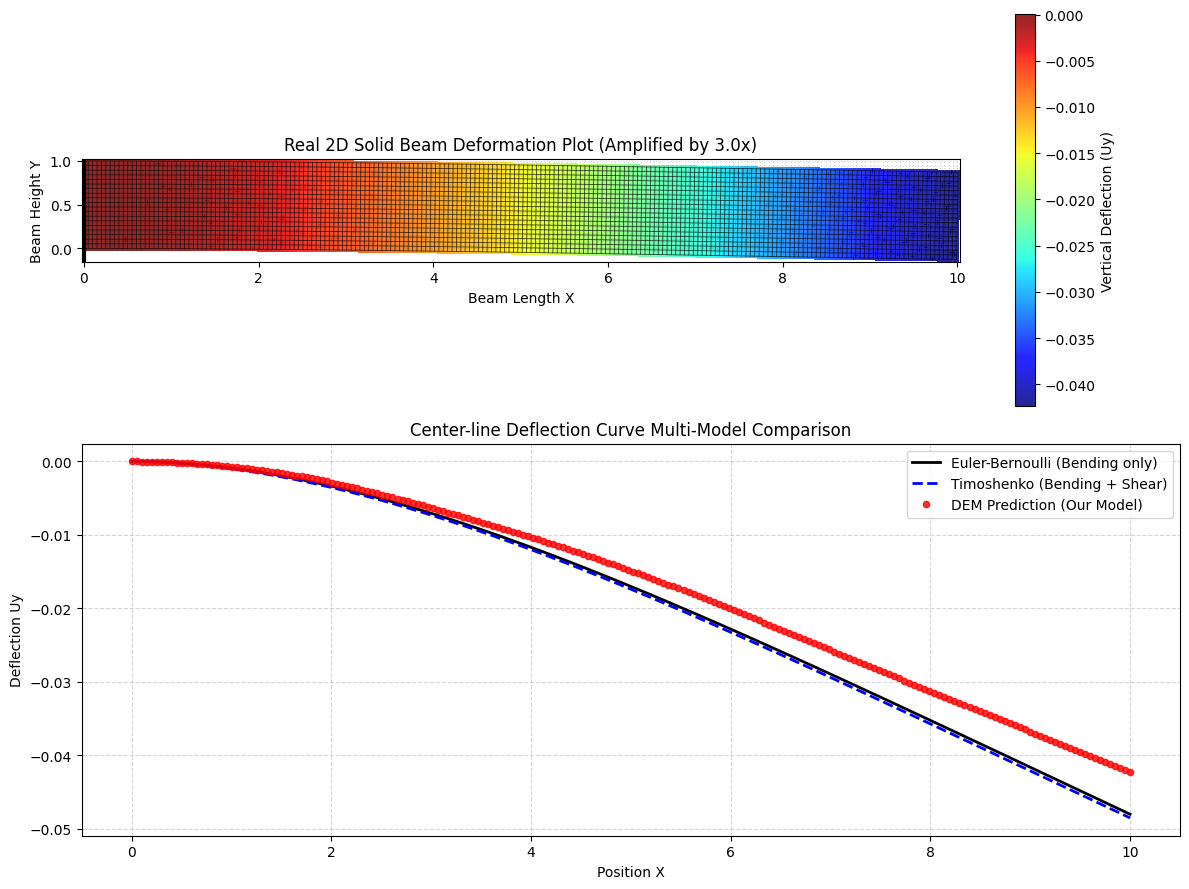

In [10]:
# 1. 幾何座標轉換與變形放大
amp_factor = 3.0  # 變形放大倍率，用來放大微小位移以利肉眼觀察
deformed_nodes = dom_nodes + u_all * amp_factor  # 幾何公式：X_def = X_orig + U * amp

# 將一維展平的數據還原回 (Ny, Nx) 的二維矩陣空間，以利 pcolormesh 繪圖
X_orig = dom_nodes[:, 0].reshape(cf.Ny, cf.Nx)  # 原始未變形 X 座標
Y_orig = dom_nodes[:, 1].reshape(cf.Ny, cf.Nx)  # 原始未變形 Y 座標
X_def = deformed_nodes[:, 0].reshape(cf.Ny, cf.Nx)  # 變形後 X 座標
Y_def = deformed_nodes[:, 1].reshape(cf.Ny, cf.Nx)  # 變形後 Y 座標
U_y_mesh = u_all[:, 1].reshape(cf.Ny, cf.Nx)  # 垂直下陷量 Uy 熱圖矩陣

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# 圖一：二維實體梁的真實變形網格與撓度熱圖

ax1.set_aspect("equal")  # 強制保持幾何長寬比 1:1，避免圖像失真

# 繪製未受力前的灰色原始網格輪廓 (虛線)
ax1.plot(X_orig, Y_orig, color="gray", alpha=0.3, linestyle=":", linewidth=0.8)
ax1.plot(X_orig.T, Y_orig.T, color="gray", alpha=0.3, linestyle=":", linewidth=0.8)

# 填滿變形後的實體梁，顏色深淺由垂直位移 Uy (U_y_mesh) 決定
contour = ax1.pcolormesh(
    X_def, Y_def, U_y_mesh, cmap="jet", shading="auto", alpha=0.85
)

# 繪製變形後的實體結構網格線 (黑色實線)
for i in range(cf.Ny):
    ax1.plot(X_def[i, :], Y_def[i, :], "k-", linewidth=0.6, alpha=0.7)
for j in range(cf.Nx):
    ax1.plot(X_def[:, j], Y_def[:, j], "k-", linewidth=0.6, alpha=0.7)

# 標註固定端牆壁邊界 (x=0)
ax1.axvline(x=0, color="black", linewidth=3, label="Fixed Support (x=0)")
ax1.title.set_text(
    f"Real 2D Solid Beam Deformation Plot (Amplified by {amp_factor}x)"
)
ax1.set_xlabel("Beam Length X")
ax1.set_ylabel("Beam Height Y")
fig.colorbar(contour, ax=ax1, label="Vertical Deflection (Uy)")


# 圖二：三方中性軸曲線精確對比 (Euler vs Timoshenko vs DEM)

# 1. 繪製經典尤拉-伯努利梁理論曲線 (黑色連續實線)
# 公式物理意義：純彎曲變形解析解
ax2.plot(
    x_space, analytical_deflection, "k-", linewidth=2, label="Euler-Bernoulli (Bending only)"
)

# 2. 繪製進階鐵木辛柯梁理論曲線 (藍色中斷虛線)
# 公式物理意義：彎曲項 + 剪切項的總和下陷曲線
# 註：這裡的 timoshenko_deflection 變數需要確保在前一段對照組程式碼中已經計算完成
ax2.plot(
    x_space,
    timoshenko_deflection,
    "b--",
    linewidth=2,
    label="Timoshenko (Bending + Shear)",
)

# 3. 繪製深度能量法神經網路預測點 (紅色圓點)
# 物理意義：由 2D 最小總位能原理自適應學習到的連續位移解
ax2.plot(
    x_space,
    dem_deflection,
    "ro",
    markersize=4.5,
    alpha=0.8,
    label="DEM Prediction (Our Model)",
)

ax2.grid(True, linestyle="--", alpha=0.5)  # 開啟網格輔助線
ax2.legend(loc="best")  # 顯示圖例，並自動選擇最佳擺放位置
ax2.title.set_text("Center-line Deflection Curve Multi-Model Comparison")
ax2.set_xlabel("Position X")
ax2.set_ylabel("Deflection Uy")

plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_1239/1507250457.py:9: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(range(len(verifier.loss_history)), verifier.loss_history, 'b-', linewidth=2, label='Total Potential Energy ($\Pi$)')


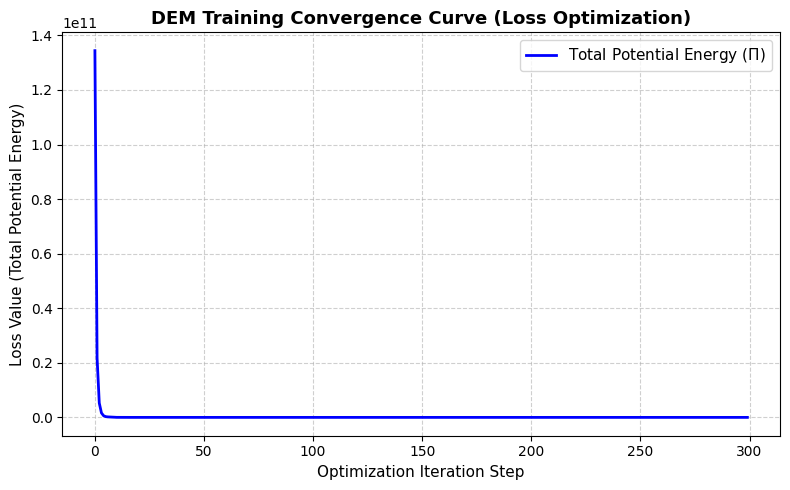

In [11]:
# 新增 Cell：繪製深度能量法 (DEM) 訓練收斂曲線 (Loss Curve)
import matplotlib.pyplot as plt

# 建立一個 8x5 英吋的收斂圖畫布
plt.figure(figsize=(8, 5))

# 繪製 Loss 下降曲線（x軸為疊代次數，y軸為總位能 Loss）
# 物理意義：這條線代表系統的「總位能」隨著訓練不斷降低，最終尋找到力學平衡態的過程。
plt.plot(range(len(verifier.loss_history)), verifier.loss_history, 'b-', linewidth=2, label='Total Potential Energy ($\Pi$)')

# 填滿美化與座標軸設定
plt.title("DEM Training Convergence Curve (Loss Optimization)", fontsize=13, fontweight='bold')
plt.xlabel("Optimization Iteration Step", fontsize=11)
plt.ylabel("Loss Value (Total Potential Energy)", fontsize=11)

# 開啟網格輔助線
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# 讓圖像緊湊顯示
plt.tight_layout()
plt.show()